## Постановка задачи

Мультиклассовая классификация по категориям товаров электронной коммерции, содержащая 4 категории:
**"Electronics" (Электроника), "Household" (Товары для дома), "Books" (Книги) и "Clothing & Accessories" (Одежда и аксессуары)**.

Датасет содержит два столбца:

* первый столбец — название класса (категории),
* второй столбец — текстовое описание к этому классу.

Характеристики датасета:
* Количество экземпляров (Number of Instances): **50425**
* Количество классов (Number of classes): **4**

In [ ]:
project_path = "/content/drive/MyDrive/nlp_classification"

In [ ]:
import sys

sys.path.append(project_path)

In [ ]:
import pandas as pd

from core.utils import init_random_seed
from core.nlp import (
    tokenize_tiktoken,
    token_counts,
    filter_tokens,
    count_based_analysis,
    punctuation_counts,
    stopwords_counts,
)
from core.visualization import (
    plot_pie_chart,
    plot_histogram_numeric,
    barplot,
    plot_wordcloud,
)

In [4]:
init_random_seed(42)

## 1. Изучение структуры данных

In [ ]:
df = pd.read_csv(f"{project_path}/ecommerceDataset.csv", names=["Category", "Text"])

In [6]:
df

,Category,Text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...
...,...,...
50420,Electronics,Strontium MicroSD Class 10 8GB Memory Card (Bl...
50421,Electronics,CrossBeats Wave Waterproof Bluetooth Wireless ...
50422,Electronics,Karbonn Titanium Wind W4 (White) Karbonn Titan...
50423,Electronics,"Samsung Guru FM Plus (SM-B110E/D, Black) Colou..."


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  50425 non-null  object
 1   Text      50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [8]:
df.duplicated().sum()

np.int64(22622)

В датасете 22622 дубликатов

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27803 entries, 0 to 27802
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  27803 non-null  object
 1   Text      27802 non-null  object
dtypes: object(2)
memory usage: 434.6+ KB


После удаления дубликатов осталось 27803 уникальных значений

### 2.2 Пропущенные значения

In [11]:
df.isnull().sum()

,0
Category,0
Text,1


In [12]:
df[df["Text"].isna()]

,Category,Text
22196,Clothing & Accessories,NaN


Присутствует один пропуск, его можно удалить

In [13]:
df = df.dropna().reset_index(drop=True)

In [14]:
df.isnull().sum()

,0
Category,0
Text,0


## 3. Детальное изучение признаков (и таргета)

In [15]:
df_EDA = df.copy()

### 3.1. Таргет (целевая переменная)

In [ ]:
df_EDA["Category"].value_counts()

,count
Category,
Household,10564
Books,6256
Clothing & Accessories,5674
Electronics,5308


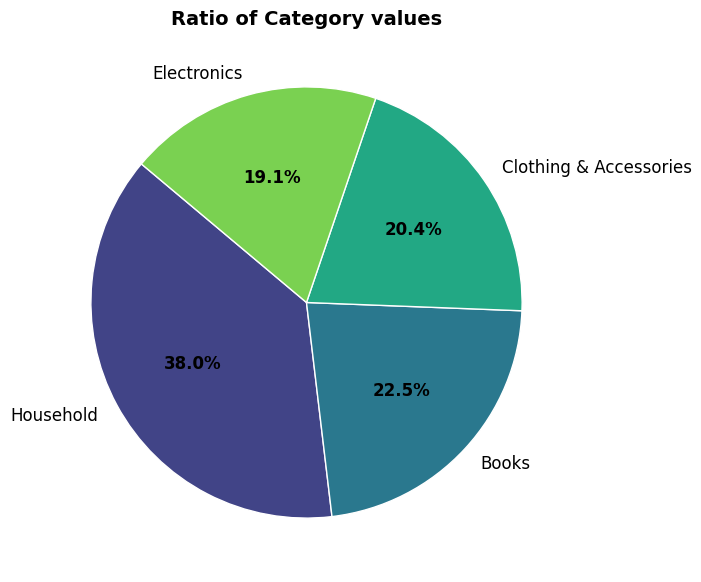

In [ ]:
plot_pie_chart(df_EDA, "Category", "Ratio of Category values")

Распределение классов в таргете достаточно равномерное. Сильного дисбаланса классов нет.

Больше всего значений класса Household (38%), меньше всего Electronics (19.1%)

### 3.2. Анализ текстовых описаний

Посчитаем длину текстовых описаний в символах

In [ ]:
df_EDA["Text_char_length"] = df_EDA["Text"].str.len()

In [ ]:
df_EDA["Text_char_length"].describe()

,Text_char_length
count,27802.000000
mean,699.994928
std,1023.019517
min,4.000000
25%,215.000000
50%,473.000000
75%,916.750000
max,50403.000000


Визуализируем распределение

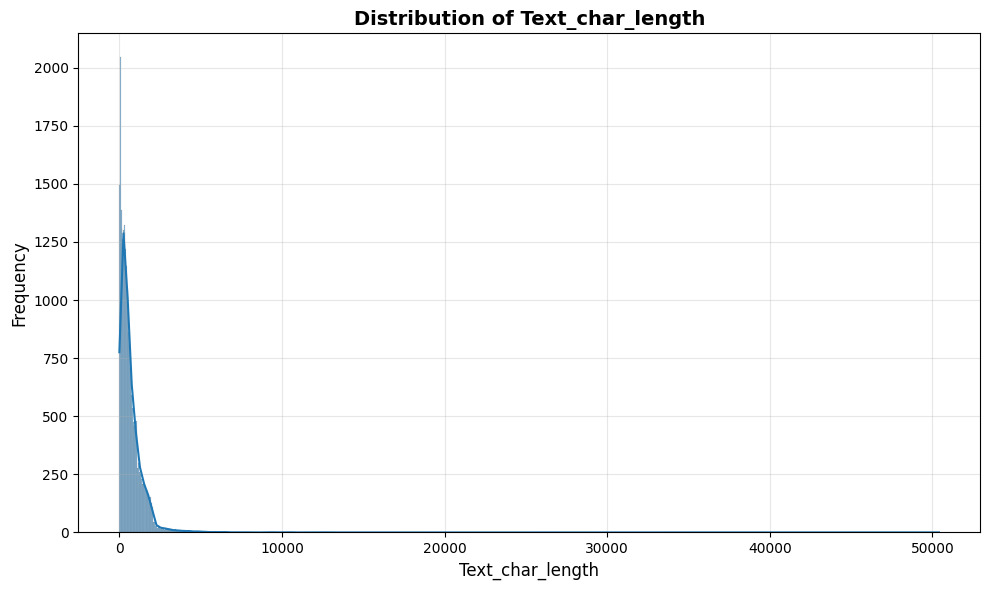

In [ ]:
plot_histogram_numeric(df_EDA, "Text_char_length", figsize=(10, 6))

Токенизируем описания и рассмотрим их длины в токенах

In [ ]:
df_EDA["Text_tokenized_tiktoken"] = df_EDA["Text"].apply(tokenize_tiktoken)
df_EDA["Text_tokenized_tiktoken_len"] = df_EDA["Text_tokenized_tiktoken"].apply(len)


Анализ знаков пунктуации в описаниях

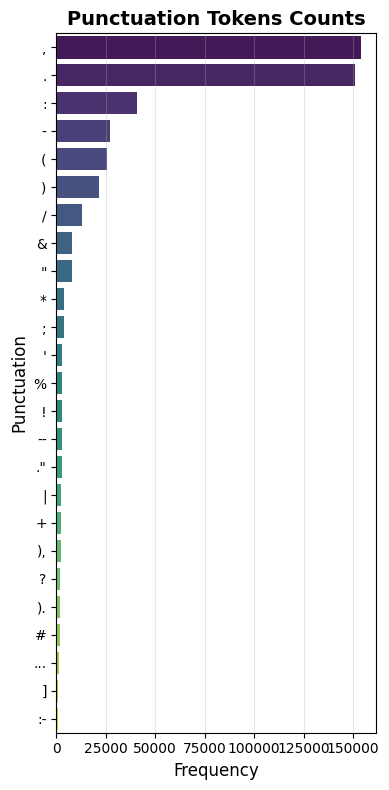

In [ ]:
punctuation_tokens_counts = punctuation_counts(df_EDA, "Text_tokenized_tiktoken")
barplot(
    punctuation_tokens_counts,
    title="Punctuation Tokens Counts",
    y_label="Punctuation",
    top_n=25,
    figsize=(4, 8),
)

Анализ стоп-слов в описаниях

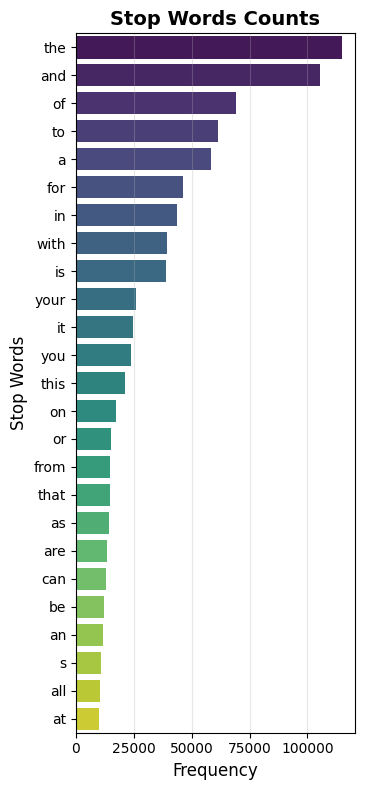

In [ ]:
stop_words_counts = stopwords_counts(df_EDA, "Text_tokenized_tiktoken")
barplot(
    stop_words_counts,
    title="Stop Words Counts",
    y_label="Stop Words",
    top_n=25,
    figsize=(4, 8),
)

Подсчет частотности каждого токена без стоп-слов и пунктуации

In [ ]:
text_token_counts = token_counts(
    df_EDA,
    "Text_tokenized_tiktoken",
    remove_stopwords=True,
    remove_punctuation=True,
    lowercase_for_counting=True,
)

Визуализация топ-50 самых частых токенов в описаниях

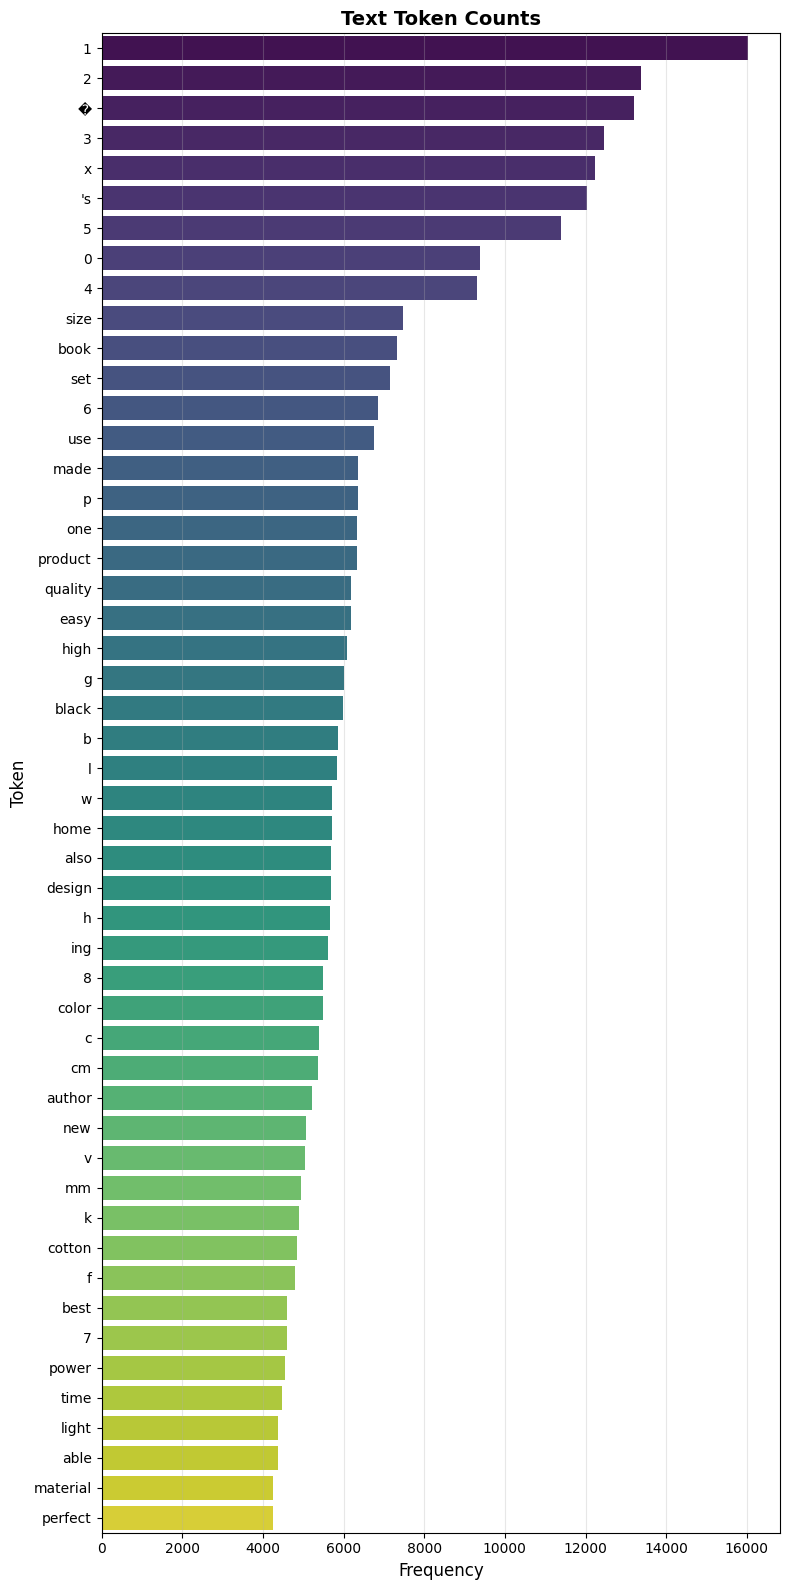

In [ ]:
barplot(
    text_token_counts,
    title="Text Token Counts",
    y_label="Token",
    top_n=50,
    figsize=(8, 16),
)

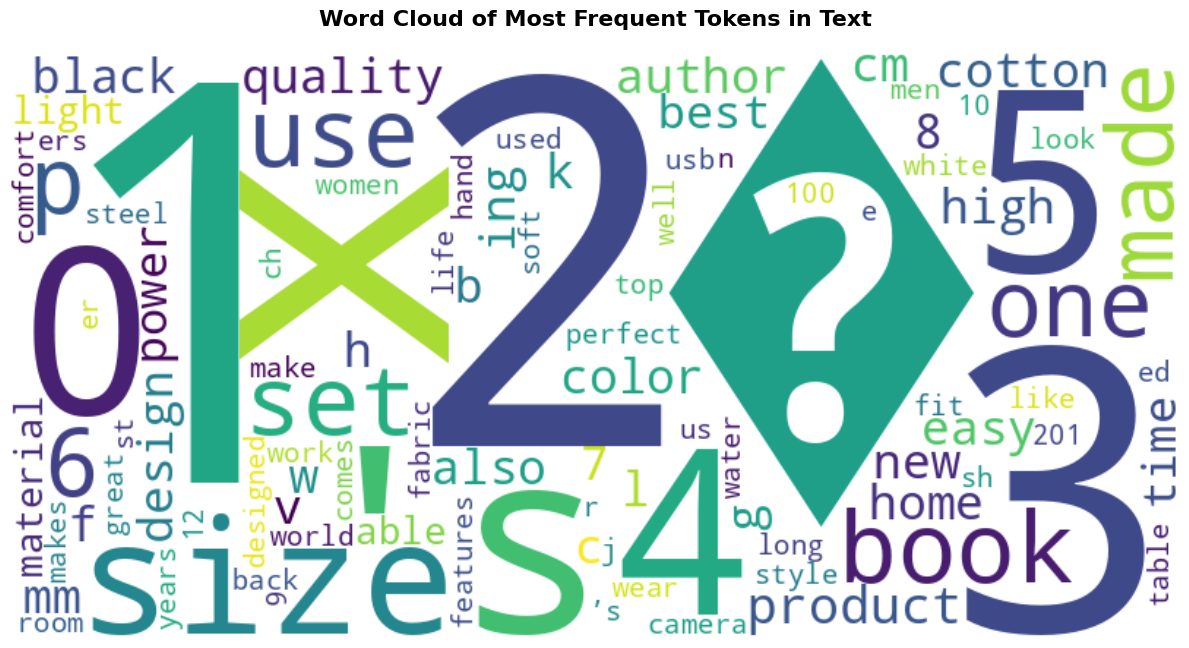

In [ ]:
plot_wordcloud(
    text_token_counts, title="Word Cloud of Most Frequent Tokens in Text", max_words=100
)

Распределение количества токенов в описаниях

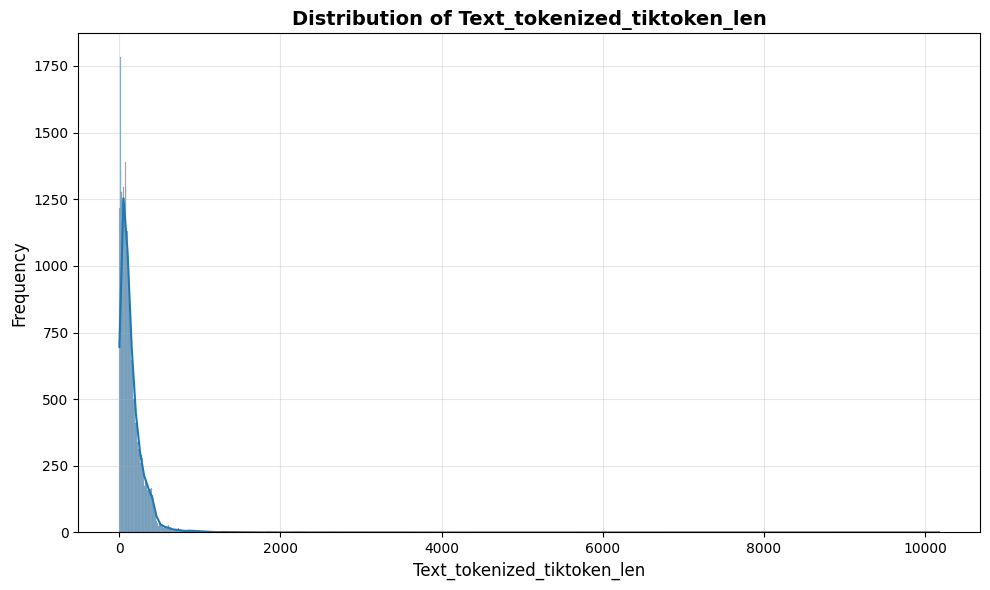

In [ ]:
plot_histogram_numeric(df_EDA, "Text_tokenized_tiktoken_len", figsize=(10, 6))

Очистим токены описания от пунктуации и стоп-слов

In [ ]:
df_EDA["Text_tokenized_tiktoken_clean"] = df_EDA["Text_tokenized_tiktoken"].apply(
    lambda tokens: filter_tokens(
        tokens,
        remove_stopwords=True,
        remove_punctuation_tokens=True,
        lowercase_for_counting=True,
    )
)


Посчитаем важность токенов для классификации. Будем использовать 1-граммы, 2-граммы и 3-граммы, а также анализировать токены, встретившиеся более 50 раз

In [ ]:
text_token_counts = count_based_analysis(
    texts_tokenized=df_EDA["Text_tokenized_tiktoken_clean"],
    labels=df_EDA["Category"],
    n=3,
    metric="anova_f",
    min_count=50,
)

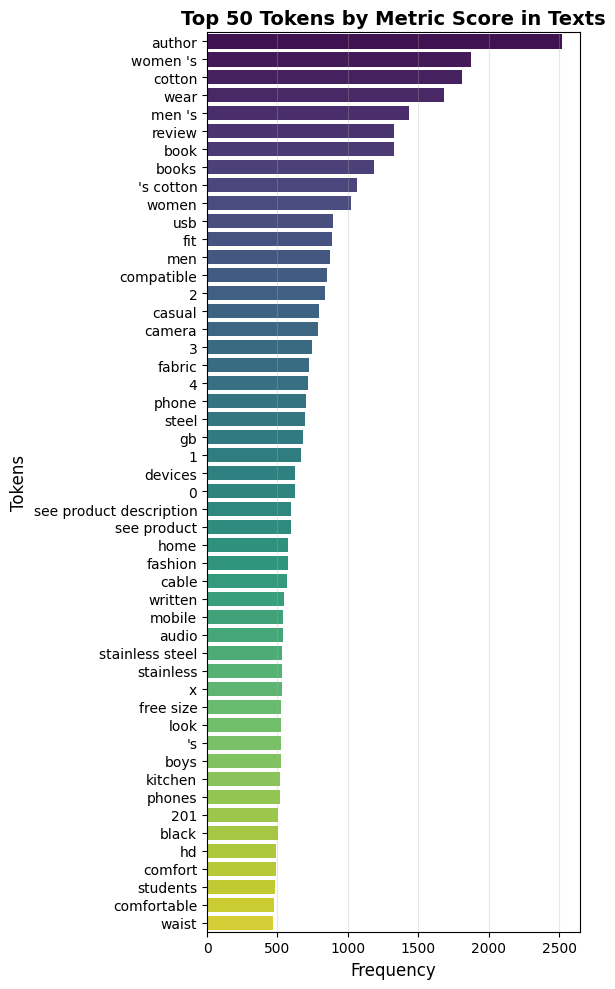

In [ ]:
barplot_data_metric = text_token_counts.set_index("token")["metric"].head(50)
barplot(
    barplot_data_metric,
    "Top 50 Tokens by Metric Score in Texts",
    "Tokens",
    figsize=(6, 10),
)

## Выводы

В ходе EDA были выявлены следующие особенности:

- В датасете было обнаружено и удалено 22622 дубликатов
- В датасете был обнаружен и удален 1 пропуск в колонке текстовых описаний
- Распределение классов в таргете достаточно равномерное. Сильного дисбаланса классов нет. Больше всего значений класса Household (38%). У классов Books (22.5%), Clothing & Accessories (20.4%) и Electronics (19.1%) проценты очень близки. При обучении нейронных сетей можно попробовать использовать параметр `weight` у CrossEntropyLoss, возможно это даст улучшение метрик
- распределения длин текстовых описаний имеют длинный правый хвост, значит необходим порог максимальной обрабатываемой длины последовательности